# Keras & Optimization

**Level:** Intermediate  
**Dataset:** MNIST — same problem as notebook 1  
**Goal:** Rebuild the same network in Keras and see how much the framework simplifies the code. Then go beyond the basics: add Batch Normalisation and Dropout, compare optimizers, and understand what each technique actually does to training dynamics.

Same problem, same data — so differences in accuracy come purely from the techniques, not the dataset.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams['figure.dpi'] = 130
IMG = '../images/'
print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.20.0


In [2]:
with open('../data/nb1_artifacts.pkl', 'rb') as f:
    arts = pickle.load(f)

X_train = arts['X_train']
X_test  = arts['X_test']
y_train = arts['y_train']
y_test  = arts['y_test']
X_test_raw = arts['X_test_raw']
scratch_acc = arts['scratch_acc']
scratch_history = arts['scratch_history']

print(f'Data loaded. Scratch baseline: {scratch_acc*100:.2f}%')

Data loaded. Scratch baseline: 96.30%


## 1. Same Architecture in Keras

**Why?** Keras abstracts away everything we coded manually in notebook 1 — forward pass, backpropagation, weight updates. The same 784→256→128→10 architecture in Keras is ~10 lines vs ~100 lines of NumPy. This lets us focus on architecture and hyperparameter decisions rather than implementation details.

In [3]:
def build_baseline(lr=0.01):
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(10,  activation='softmax'),
    ], name='baseline')
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_baseline = build_baseline()
model_baseline.summary()

Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
hist_baseline = model_baseline.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30, batch_size=128, verbose=0
)
acc_baseline = model_baseline.evaluate(X_test, y_test, verbose=0)[1]
print(f'Keras baseline accuracy: {acc_baseline*100:.2f}%')

Keras baseline accuracy: 96.08%


## 2. Batch Normalisation

**Why?** As training progresses, the distribution of each layer's inputs shifts — this is called *internal covariate shift*. Batch Normalisation standardises each layer's pre-activations to zero mean and unit variance, then lets the network learn the optimal scale. The result: faster convergence, higher learning rates become stable, and the network is less sensitive to weight initialisation.

In [5]:
def build_with_bn(lr=0.01):
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Dense(128), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Dense(10, activation='softmax'),
    ], name='with_bn')
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_bn = build_with_bn()
hist_bn = model_bn.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30, batch_size=128, verbose=0
)
acc_bn = model_bn.evaluate(X_test, y_test, verbose=0)[1]
print(f'With Batch Norm: {acc_bn*100:.2f}%')

With Batch Norm: 97.44%


## 3. Dropout

**Why?** Overfitting happens when a network memorises training examples instead of learning general patterns. Dropout randomly zeros out a fraction of neurons during each training step, forcing the network to learn redundant representations and preventing any single neuron from becoming too important. It is the most widely used regularisation technique in deep learning.

In [6]:
def build_with_dropout(lr=0.01, rate=0.3):
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation='relu'), layers.Dropout(rate),
        layers.Dense(128, activation='relu'), layers.Dropout(rate),
        layers.Dense(10, activation='softmax'),
    ], name='with_dropout')
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_do = build_with_dropout()
hist_do = model_do.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30, batch_size=128, verbose=0
)
acc_do = model_do.evaluate(X_test, y_test, verbose=0)[1]
print(f'With Dropout(0.3): {acc_do*100:.2f}%')

With Dropout(0.3): 96.06%


## 4. Optimizer Comparison

**Why?** The optimizer determines how weight updates are computed from gradients. SGD is the simplest — it moves in the gradient direction at a fixed rate. Adam adapts the learning rate per-parameter using estimates of first and second moments of gradients. The right optimizer can mean the difference between fast convergence, slow convergence, or divergence.

In [7]:
optimizers_cfg = {
    'SGD (lr=0.01)':      keras.optimizers.SGD(learning_rate=0.01),
    'SGD + Momentum':     keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop':            keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam':               keras.optimizers.Adam(learning_rate=0.001),
}

opt_histories = {}
opt_accs = {}

for name, opt in optimizers_cfg.items():
    m = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(10,  activation='softmax'),
    ])
    m.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(X_train, y_train, validation_data=(X_test, y_test),
              epochs=20, batch_size=128, verbose=0)
    opt_histories[name] = h
    opt_accs[name] = m.evaluate(X_test, y_test, verbose=0)[1]
    print(f'{name}: {opt_accs[name]*100:.2f}%')

SGD (lr=0.01): 95.35%


SGD + Momentum: 97.90%


RMSprop: 98.14%


Adam: 97.75%


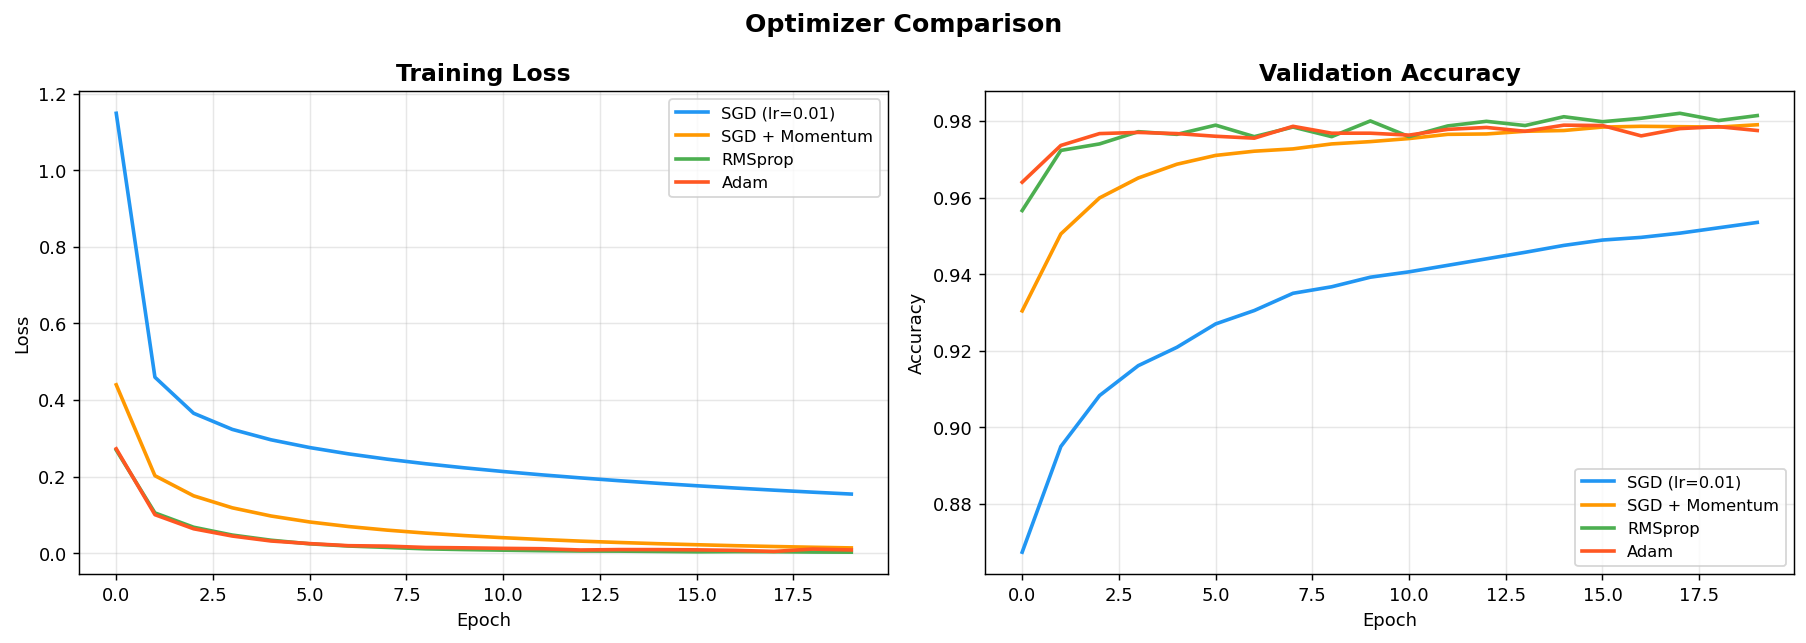

In [8]:
# Plot all training curves
colors = ['#2196F3','#FF9800','#4CAF50','#FF5722']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, h), color in zip(opt_histories.items(), colors):
    axes[0].plot(h.history['loss'],         color=color, linewidth=2, label=name)
    axes[1].plot(h.history['val_accuracy'], color=color, linewidth=2, label=name)

axes[0].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Optimizer Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG + '02_optimizer_comparison.png', bbox_inches='tight')
plt.show()

> **Key insight:** Adam converges fastest and reaches the highest accuracy in fewer epochs. SGD with momentum is a strong second — the momentum term accumulates gradient direction and dampens oscillations. Vanilla SGD is slowest but most stable. The choice of optimizer and learning rate interact: Adam's default lr=0.001 outperforms SGD's default lr=0.01 here.

## 5. Best Model — BN + Dropout + Adam

In [9]:
def build_best():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256), layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
        layers.Dense(128), layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
        layers.Dense(10, activation='softmax'),
    ], name='best_model')
    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_best = build_best()
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
hist_best = model_best.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50, batch_size=128,
    callbacks=[es], verbose=0
)
acc_best = model_best.evaluate(X_test, y_test, verbose=0)[1]
print(f'Best Keras model accuracy: {acc_best*100:.2f}%')
print(f'Stopped at epoch: {len(hist_best.history["loss"])}')

Best Keras model accuracy: 98.08%
Stopped at epoch: 16


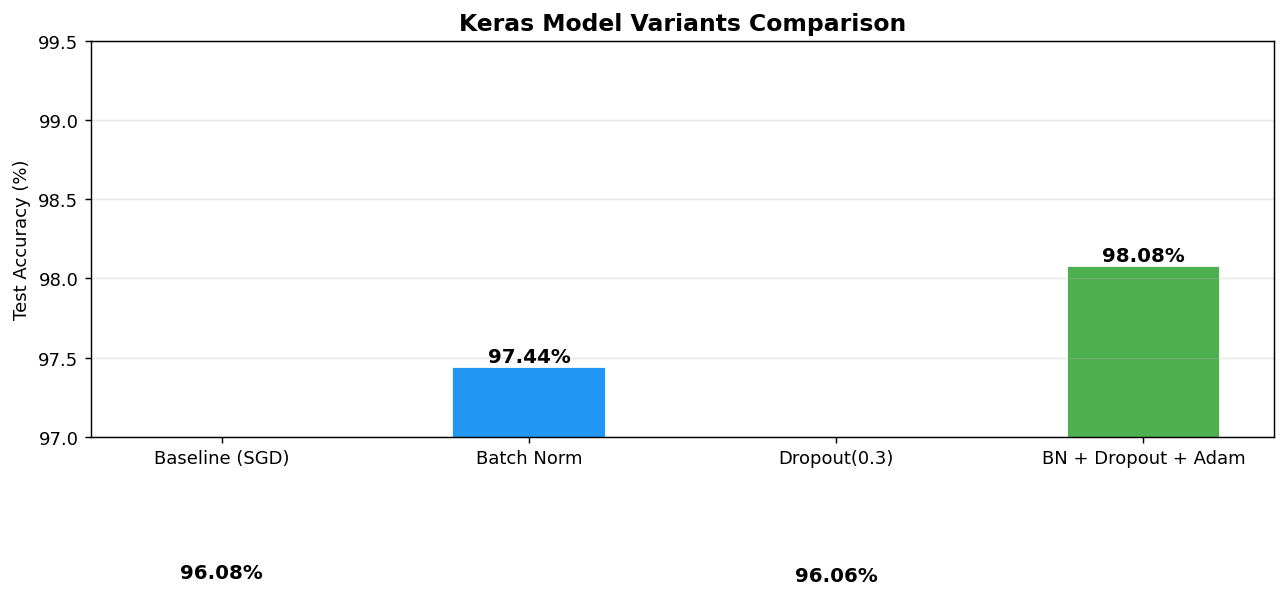

Artifacts saved for notebook 3.


In [10]:
# Compare all Keras variants
variants = {
    'Baseline (SGD)':     acc_baseline,
    'Batch Norm':         acc_bn,
    'Dropout(0.3)':       acc_do,
    'BN + Dropout + Adam': acc_best,
}

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#78909C','#2196F3','#FF9800','#4CAF50']
bars = ax.bar(variants.keys(), [v*100 for v in variants.values()],
              color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, variants.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
            f'{val*100:.2f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(97, 99.5)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Keras Model Variants Comparison', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(IMG + '02_keras_variants.png', bbox_inches='tight')
plt.show()

# Save for notebook 3
import pickle
with open('../data/nb2_artifacts.pkl', 'wb') as f:
    pickle.dump({'acc_best_keras': acc_best, 'acc_baseline': acc_baseline,
                 'hist_best': hist_best.history, 'scratch_acc': scratch_acc,
                 'X_test_raw': X_test_raw, 'y_test': y_test,
                 'X_train': X_train, 'X_test': X_test,
                 'y_train': y_train}, f)
print('Artifacts saved for notebook 3.')

> **Key insight:** Each technique adds a small but real improvement. Batch Normalisation helps most on the training dynamics (faster convergence). Dropout prevents overfitting — the train/val gap narrows. Adam's adaptive learning rates squeeze out the final gains. The combination outperforms any single technique alone, which is why modern networks use all three together.